# Exercise 4. Theory-oriented quantitative test

This notebook implements the special case used in the final question. The idea is to make the 1D model linear by choosing a large positive background, then initialize the network with one cosine wave. In this case the cosine shape should not change; only its amplitude should decay by an exactly known factor at each Euler step.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from helper import mexican_hat_1d, circular_distances, periodic_convolve1d

# In the report folder, figures live one level above source_code/.
FIGURES_DIR = Path("../figures") if Path.cwd().name == "source_code" else Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## Exact special case

We use the Exercise 0 one-dimensional model with periodic boundary conditions. The background input is chosen large enough that all potentials stay positive, so the rectification is simply `r=s`. Then the dynamics is linear.

The initial condition is a uniform fixed point plus one cosine wave:

$$
s_i(0)=S^*+a_0\cos\left(\frac{2\pi k i}{M}\right).
$$

For this special case, the cosine wave remains a cosine wave. Only its amplitude changes. With forward Euler integration, the exact amplitude after `n` steps is

$$
a_n=a_0\left[1+\frac{\Delta t}{\tau}(\lambda_k-1)\right]^n.
$$


In [2]:
M = 100
tau_ms = 10.0
dt_ms = 1.0
B = 10.0
k = 3
a0 = 0.1
n_steps = 60

indices = np.arange(M)
distances = circular_distances(M)
K = mexican_hat_1d(
    distances,
    A_exc=0.3,
    sigma_exc=5.0,
    A_inh=0.2,
    sigma_inh=10.0,
)

cos_mode = np.cos(2 * np.pi * k * indices / M)

# These are the eigenvalues of the actual discrete convolution used by the code.
lambda0 = periodic_convolve1d(np.ones(M), K)[0]
lambda_k = np.dot(periodic_convolve1d(cos_mode, K), cos_mode) / np.dot(cos_mode, cos_mode)

S_star = B / (1.0 - lambda0)
q_k = 1.0 + (dt_ms / tau_ms) * (lambda_k - 1.0)

print(f"lambda_0 = {lambda0:.10f}")
print(f"lambda_{k} = {lambda_k:.10f}")
print(f"S* = {S_star:.10f}")
print(f"q_{k} = {q_k:.10f}")
print(f"minimum initial s_i = {S_star - a0:.4f}")


lambda_0 = -0.8862269254
lambda_3 = 0.6709720205
S* = 5.3015890427
q_3 = 0.9670972021
minimum initial s_i = 5.2016


In [3]:
# Initial condition: fixed background plus one cosine perturbation.
s = S_star + a0 * cos_mode

steps = np.arange(n_steps + 1)
amplitudes_sim = np.zeros(n_steps + 1)

for n in steps:
    # Project the current state onto the same cosine mode.
    amplitudes_sim[n] = np.dot(s - S_star, cos_mode) / np.dot(cos_mode, cos_mode)

    # Stop after recording the final step.
    if n == n_steps:
        break

    # One Euler step of the original model. ReLU has no effect here because s stays positive.
    recurrent = periodic_convolve1d(np.maximum(0.0, s), K)
    s = s + (dt_ms / tau_ms) * (-s + recurrent + B)

amplitudes_theory = a0 * q_k ** steps
relative_error = np.abs(amplitudes_sim - amplitudes_theory) / np.abs(amplitudes_theory)

check_step = 20
print(f"theory amplitude at step {check_step} = {amplitudes_theory[check_step]:.10f}")
print(f"simulated amplitude at step {check_step} = {amplitudes_sim[check_step]:.10f}")
print(f"relative error at step {check_step} = {relative_error[check_step]:.3e}")
print(f"max relative error over all steps = {relative_error.max():.3e}")


theory amplitude at step 20 = 0.0512156320
simulated amplitude at step 20 = 0.0512156320
relative error at step 20 = 1.084e-15
max relative error over all steps = 1.811e-14


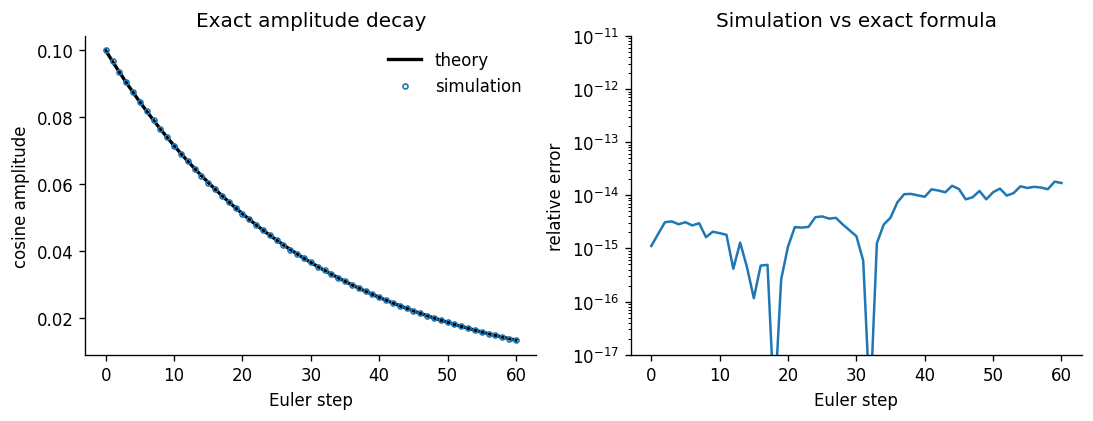

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), constrained_layout=True)

axes[0].plot(steps, amplitudes_theory, color="black", linewidth=2, label="theory")
axes[0].plot(steps, amplitudes_sim, "o", markersize=3, markerfacecolor="none", label="simulation")
axes[0].set_xlabel("Euler step")
axes[0].set_ylabel("cosine amplitude")
axes[0].set_title("Exact amplitude decay")
axes[0].legend(frameon=False)

axes[1].semilogy(steps, relative_error + 1e-18, color="tab:blue")
axes[1].set_xlabel("Euler step")
axes[1].set_ylabel("relative error")
axes[1].set_title("Simulation vs exact formula")
axes[1].set_ylim(1e-17, 1e-11)

fig.savefig(FIGURES_DIR / "ex41_fourier_test.png", bbox_inches="tight")
plt.show()


The simulated amplitude and the exact formula agree up to numerical roundoff. This verifies the convolution convention, the periodic boundary condition, and the Euler update in a case where the correct answer is known in advance.